## Question 1: Can the foveal neuron activity pattern decode the target cathegory BEFORE the saccade?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import pickle
import aux_functions as aux
importlib.reload(aux)

<module 'aux_functions' from 'e:\\vispred\\aux_functions.py'>

In [2]:
MONKEY = 'M08'
SESSION = 'm08cat255'
STR_DETAILS = f'Session {SESSION}'

filter_area = True
AREA = 'V4'
# AREA = 'TE'

filter_RF = True
RF_USE = 'Focal Foveal'

In [3]:
with open(f"session_data/{SESSION}.pkl", "rb") as file:
# with open(f"session_data\\{SESSION}.pkl", "rb") as file:
    df_session= pickle.load(file)
df_session

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,
0,847,m08cat255spk033a,m08det254spk033a,-1+5,1186,TE,0.0,NaN,face,0.38549,NaN,NaN,Focal Foveal,m08cat255,spk033a,NaN,NaN
1,848,m08cat255spk033z,m08det254spk033z,-1+5,1186,TE,0.0,NaN,face,0.51208,NaN,NaN,Focal Foveal,m08cat255,spk033z,NaN,NaN
2,849,m08cat255spk034a,m08det254spk034a,-1+5,1346,TE,0.0,NaN,face,0.60449,NaN,NaN,Focal Foveal,m08cat255,spk034a,NaN,NaN
3,850,m08cat255spk034b,m08det254spk034b,-1+5,1346,TE,0.0,NaN,face,1.00000,NaN,NaN,Focal Foveal,m08cat255,spk034b,NaN,NaN
4,851,m08cat255spk034c,m08det254spk034c,-1+5,1346,TE,0.0,0.0,face,0.56654,"0,8,19","1,2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,20",Broad Foveal,m08cat255,spk034c,"0,8,19",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,1140,m08cat255spk091b,m08det254spk091b,B+4-4,720,VPA,0.0,0.0,NaN,0.13946,NaN,NaN,Broad Foveal,m08cat255,spk091b,NaN,NaN
227,1141,m08cat255spk091z,m08det254spk091z,B+4-4,720,VPA,NaN,0.0,NaN,NaN,NaN,NaN,Peripheral,m08cat255,spk091z,NaN,NaN
228,1142,m08cat255spk093b,m08det254spk093b,B+4-4,735,VPA,0.0,0.0,NaN,-0.36007,NaN,NaN,Broad Foveal,m08cat255,spk093b,NaN,NaN
229,1143,m08cat255spk095a,m08det254spk095a,B+4-4,750,VPA,NaN,0.0,NaN,NaN,NaN,NaN,Peripheral,m08cat255,spk095a,NaN,NaN


In [4]:
df_session['brain_area'].value_counts()

TE     106
V4      87
VPA     38
Name: brain_area, dtype: int64

In [5]:
# df_session = df_session[df_session['brain_area'].isin(AREA)]
df_session = df_session[df_session['brain_area']==AREA]
STR_DETAILS += f' {AREA}'
df_session

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,
106,2055,m08cat255spk097z,m08det254spk097z,+3-3,716,V4,0.0,NaN,NaN,-0.285580,NaN,NaN,Focal Foveal,m08cat255,spk097z,NaN,NaN
107,2056,m08cat255spk098a,m08det254spk098a,+3-3,876,V4,0.0,NaN,face,0.108970,NaN,NaN,Focal Foveal,m08cat255,spk098a,NaN,NaN
108,2057,m08cat255spk098b,m08det254spk098b,+3-3,876,V4,0.0,NaN,face,0.176950,NaN,NaN,Focal Foveal,m08cat255,spk098b,NaN,NaN
109,2058,m08cat255spk098z,m08det254spk098z,+3-3,876,V4,0.0,NaN,NaN,0.026967,NaN,NaN,Focal Foveal,m08cat255,spk098z,NaN,NaN
110,2059,m08cat255spk099a,m08det254spk099a,+3-3,726,V4,0.0,NaN,NaN,-0.085379,NaN,NaN,Focal Foveal,m08cat255,spk099a,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2137,m08cat255spk128a,m08det254spk128a,+3-3,1026,V4,0.0,NaN,face,0.206230,NaN,NaN,Focal Foveal,m08cat255,spk128a,NaN,NaN
189,2138,m08cat255spk128b,m08det254spk128b,+3-3,1026,V4,0.0,NaN,face,0.233680,NaN,NaN,Focal Foveal,m08cat255,spk128b,NaN,NaN
190,2139,m08cat255spk128c,m08det254spk128c,+3-3,1026,V4,0.0,NaN,face,0.690970,NaN,NaN,Focal Foveal,m08cat255,spk128c,NaN,NaN
191,2140,m08cat255spk128d,m08det254spk128d,+3-3,1026,V4,0.0,NaN,face,1.000000,NaN,NaN,Focal Foveal,m08cat255,spk128d,NaN,NaN


In [6]:
df_session['RF_type'].value_counts()

Focal Foveal    87
Name: RF_type, dtype: int64

In [7]:
df_session = df_session[df_session['RF_type'] == RF_USE]
STR_DETAILS += f' {RF_USE}'
STR_DETAILS

'Session m08cat255 V4 Focal Foveal'

In [8]:
df_session

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,
106,2055,m08cat255spk097z,m08det254spk097z,+3-3,716,V4,0.0,NaN,NaN,-0.285580,NaN,NaN,Focal Foveal,m08cat255,spk097z,NaN,NaN
107,2056,m08cat255spk098a,m08det254spk098a,+3-3,876,V4,0.0,NaN,face,0.108970,NaN,NaN,Focal Foveal,m08cat255,spk098a,NaN,NaN
108,2057,m08cat255spk098b,m08det254spk098b,+3-3,876,V4,0.0,NaN,face,0.176950,NaN,NaN,Focal Foveal,m08cat255,spk098b,NaN,NaN
109,2058,m08cat255spk098z,m08det254spk098z,+3-3,876,V4,0.0,NaN,NaN,0.026967,NaN,NaN,Focal Foveal,m08cat255,spk098z,NaN,NaN
110,2059,m08cat255spk099a,m08det254spk099a,+3-3,726,V4,0.0,NaN,NaN,-0.085379,NaN,NaN,Focal Foveal,m08cat255,spk099a,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2137,m08cat255spk128a,m08det254spk128a,+3-3,1026,V4,0.0,NaN,face,0.206230,NaN,NaN,Focal Foveal,m08cat255,spk128a,NaN,NaN
189,2138,m08cat255spk128b,m08det254spk128b,+3-3,1026,V4,0.0,NaN,face,0.233680,NaN,NaN,Focal Foveal,m08cat255,spk128b,NaN,NaN
190,2139,m08cat255spk128c,m08det254spk128c,+3-3,1026,V4,0.0,NaN,face,0.690970,NaN,NaN,Focal Foveal,m08cat255,spk128c,NaN,NaN
191,2140,m08cat255spk128d,m08det254spk128d,+3-3,1026,V4,0.0,NaN,face,1.000000,NaN,NaN,Focal Foveal,m08cat255,spk128d,NaN,NaN


In [9]:
df_session['prefer'].fillna('NaN',inplace=False).value_counts()

face    54
NaN     33
Name: prefer, dtype: int64

In [10]:
STR_DETAILS

'Session m08cat255 V4 Focal Foveal'

In [11]:
importlib.reload(aux)

<module 'aux_functions' from 'e:\\vispred\\aux_functions.py'>

In [12]:
# path_destiny = f'dados\\{MONKEY}_neurons\\neurons sorted' # windows
path_destiny = f'dados/{MONKEY}_neurons/neurons sorted' # linux
list_neuron_ids = df_session['search']
list_prefered_cat = df_session['prefer']
list_brain_area = df_session['brain_area']
list_RF_type = df_session['RF_type']

# OBS: spike times here stop in the END OF THE FIRST FIX!!! We can alter later for posterior analysis.
df_trials = aux.get_df_trials(list_neuron_ids, path_destiny, list(list_prefered_cat), list(list_brain_area), list(list_RF_type), firings_cue_and_array=True)
df_trials

,neuron,prefered,brain_area,RF_type,trial_num,clue_id,clue_cath,imgsacc_id,imgsacc_cath,pre_sacc_time,...,clue_on,clue_off,FP_back,array_on,sacc_start,start_first_fix,end_first_fix,firings,firings_cue,firings_array
0,m08cat255spk097z,NaN,V4,Focal Foveal,3,1020.0,flower,2030.0,house,0.137433,...,5.580300,6.266300,6.266667,6.793967,6.931400,6.947333,7.057100,"[-1.6521999999999997, -1.5935333333333332, -1....","[-0.3010999999999999, -0.2424333333333335, -0....","[-1.5147666666666666, -1.4561000000000002, -1...."
1,m08cat255spk097z,NaN,V4,Focal Foveal,4,3022.0,face,3022.0,face,0.155533,...,9.634067,10.168367,10.168700,10.675167,10.830700,10.832767,11.640533,"[-1.6550333333333338, -1.5921666666666674, -1....","[-0.45840000000000103, -0.3955333333333346, -0...","[-1.4994999999999994, -1.436633333333333, -1.4..."
2,m08cat255spk097z,NaN,V4,Focal Foveal,5,2020.0,house,3005.0,face,0.165867,...,13.105633,13.931633,13.932000,14.438333,14.604200,14.607900,14.794833,"[-1.7332, -1.6857333333333333, -1.611033333333...","[-0.23463333333333303, -0.18716666666666626, -...","[-1.5673333333333321, -1.5198666666666654, -1...."
3,m08cat255spk097z,NaN,V4,Focal Foveal,7,3019.0,face,1017.0,flower,0.163433,...,19.750333,20.874867,20.875200,21.381600,21.545033,21.547100,21.694867,"[-2.4454666666666647, -2.2130666666666663, -2....","[-0.6507666666666658, -0.41836666666666744, -0...","[-2.282033333333331, -2.0496333333333325, -2.0..."
4,m08cat255spk097z,NaN,V4,Focal Foveal,8,2013.0,house,3019.0,face,0.139000,...,24.096733,24.610267,24.610633,25.117100,25.256100,25.259900,25.462067,"[-1.5441000000000003, -1.539366666666666, -1.4...","[-0.38473333333333315, -0.379999999999999, -0....","[-1.405100000000001, -1.4003666666666668, -1.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150679,m08cat255spk128z,NaN,V4,Focal Foveal,2657,3007.0,face,2024.0,house,0.139367,...,12807.014333,12807.576533,12807.576900,12808.083233,12808.222600,12808.226200,12808.469667,"[-1.6588333333329501, -1.5046333333320945, -1....","[-0.4505666666664183, -0.29636666666556266, -0...","[-1.5194666666666308, -1.3652666666657751, -1...."
150680,m08cat255spk128z,NaN,V4,Focal Foveal,2658,2051.0,house,4020.0,hand,0.144167,...,12811.201200,12811.749333,12811.749700,12812.256100,12812.400267,12812.402700,12812.405467,"[-1.7314333333342802, -1.6982333333344286, -1....","[-0.5323666666663485, -0.4991666666664969, -0....","[-1.5872666666673467, -1.5540666666674952, -1...."
150681,m08cat255spk128z,NaN,V4,Focal Foveal,2662,3017.0,face,2019.0,house,0.149333,...,12825.643000,12826.913367,12826.913733,12827.420033,12827.569367,12827.571467,12827.975533,"[-2.538266666666459, -2.440233333332799, -2.42...","[-0.6118999999998778, -0.5138666666662175, -0....","[-2.3889333333336253, -2.290899999999965, -2.2..."
150682,m08cat255spk128z,NaN,V4,Focal Foveal,2663,2050.0,house,2019.0,house,0.122767,...,12833.072167,12833.800967,12833.801333,12834.307667,12834.430433,12834.437167,12834.572567,"[-4.30256666666719, -4.272266666666837, -4.268...","[-2.9443000000010215, -2.9140000000006694, -2....","[-4.1798000000017055, -4.149500000001353, -4.1..."


In [13]:
STR_DETAILS_fix = STR_DETAILS

## Plotting session details

In [13]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

def get_trial_spike_array(spikes_sec, window_start_ms, window_end_ms):
    """
    Função base que extrai e converte os tempos de disparo de uma única trial 
    em um array binário (0s e 1s) para os bins de milissegundos.
    """
    time_bins = np.arange(window_start_ms, window_end_ms)
    num_bins = len(time_bins)
    spike_array = np.zeros(num_bins)
    
    start_sec = window_start_ms / 1000.0
    end_sec = window_end_ms / 1000.0
    
    # Filtra os spikes dentro da janela
    trial_spikes = spikes_sec[(spikes_sec >= start_sec) & (spikes_sec < end_sec)]
    
    # Converte para milissegundos
    relative_spikes_ms = np.floor(trial_spikes * 1000).astype(int)
    
    # Preenche o array binário
    for spk_ms in relative_spikes_ms:
        bin_idx = spk_ms - window_start_ms
        if 0 <= bin_idx < num_bins:
            spike_array[bin_idx] += 1
            
    return spike_array


def plot_single_trial(row, window_start_ms=-1500, window_end_ms=500):
    """
    PARA CADA LINHA: Gera o gráfico de taxa de disparo para UMA tentativa (linha),
    mostrando os tempos EXATOS da Pista e do Array que ocorreram naquela tentativa.
    
    Args:
        row: Uma linha do DataFrame (pode ser df_trials.iloc[i] ou um itertuple).
    """
    spikes_sec = np.array(row.firings)
    spike_array = get_trial_spike_array(spikes_sec, window_start_ms, window_end_ms)
    
    # Filtro Gaussiano para suavizar a trial única
    firing_rate = gaussian_filter1d(spike_array, sigma=20) * 1000
    time_bins = np.arange(window_start_ms, window_end_ms)
    
    plt.figure(figsize=(10, 4))
    plt.plot(time_bins, firing_rate, color='black', linewidth=1.5)
    plt.axvline(x=0, color='red', linestyle='-', label='Sacada (t=0)')
    
    # Adiciona marcadores específicos DESTA trial se existirem (distância relativa à sacada)
    if hasattr(row, 'clue_on') and hasattr(row, 'sacc_start') and not pd.isna(row.clue_on):
        rel_cue = (row.clue_on - row.sacc_start) * 1000
        if window_start_ms <= rel_cue <= window_end_ms:
            plt.axvline(x=rel_cue, color='green', linestyle='--', label=f'Pista ({rel_cue:.0f} ms)')
            
    if hasattr(row, 'array_on') and hasattr(row, 'sacc_start') and not pd.isna(row.array_on):
        rel_array = (row.array_on - row.sacc_start) * 1000
        if window_start_ms <= rel_array <= window_end_ms:
            plt.axvline(x=rel_array, color='blue', linestyle='-.', label=f'Array ({rel_array:.0f} ms)')

    plt.title('PSTH Trial Única - Alinhado pela Sacada', fontsize=12)
    plt.xlabel('Tempo em relação à Sacada (ms)', fontsize=10)
    plt.ylabel('Taxa de Disparo (Hz)', fontsize=10)
    plt.xlim(window_start_ms, window_end_ms)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_psth_aligned_with_markers(df, time_column, title_suffix, window_start_ms, window_end_ms, markers=None):
    """
    OUTRA FUNÇÃO (Gráfico Médio): Usa a primeira função `get_trial_spike_array` 
    para compilar todas as linhas e gerar a média populacional.
    """
    time_bins = np.arange(window_start_ms, window_end_ms)
    num_bins = len(time_bins)
    num_trials = len(df)
    
    spike_matrix = np.zeros((num_trials, num_bins))
    
    # Usa a função base para processar linha a linha
    for i, row in enumerate(df.itertuples()):
        spikes_sec = np.array(getattr(row, time_column))
        spike_matrix[i, :] = get_trial_spike_array(spikes_sec, window_start_ms, window_end_ms)

    # Média e Filtro Gaussiano
    mean_spikes = np.mean(spike_matrix, axis=0)
    firing_rate = gaussian_filter1d(mean_spikes, sigma=20) * 1000

    # ==========================================
    # Plotagem
    # ==========================================
    plt.figure(figsize=(12, 6))
    plt.plot(time_bins, firing_rate, color='black', linewidth=2)
    
    plt.axvline(x=0, color='red', linestyle='-', label=f'{title_suffix} Onset (t=0)')

    # Adicionando os Marcadores Secundários (min, max, mean)
    if markers:
        for marker in markers:
            times = np.array(marker['times'])
            times = times[~np.isnan(times)] 
            
            if len(times) == 0:
                continue
                
            min_t, max_t, mean_t = np.min(times), np.max(times), np.mean(times)
            color = marker.get('color', 'blue')
            label = marker.get('label', 'Event')
            ls = marker.get('linestyle', '--')

            plt.axvline(x=min_t, color=color, linestyle=':', label=f'{label} Min ({min_t:.0f} ms)')
            plt.axvline(x=mean_t, color=color, linestyle=ls, label=f'{label} Mean ({mean_t:.0f} ms)')
            plt.axvline(x=max_t, color=color, linestyle=':', label=f'{label} Max ({max_t:.0f} ms)')
            plt.axvspan(min_t, max_t, color=color, alpha=0.1)

    plt.title(f'{STR_DETAILS} | PSTH Médio - Alinhado por {title_suffix}', fontsize=14)
    plt.xlabel(f'Tempo em relação a {title_suffix} (ms)', fontsize=12)
    plt.ylabel('Taxa de Disparo (Hz)', fontsize=12)
    plt.xlim(window_start_ms, window_end_ms)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_mean_saccade_from_df(df_trials, window_start_ms=-1500, window_end_ms=500):
    """
    Função facilitadora que automatiza a geração do gráfico médio alinhado pela sacada,
    calculando automaticamente os tempos relativos (min, max, mean) usando as colunas
    'clue_on', 'array_on' e 'sacc_start' do seu DataFrame.
    """
    print("Calculando tempos relativos a partir do DataFrame...")
    
    # Calcula os tempos relativos da pista e do array em relação ao início da sacada
    rel_cue_from_sac = (df_trials['clue_on'] - df_trials['sacc_start']) * 1000
    rel_array_from_sac = (df_trials['array_on'] - df_trials['sacc_start']) * 1000
    
    # Cria a lista de marcadores para a função de plotagem
    markers_sac = [
        {'label': 'Pista (Cue)', 'times': rel_cue_from_sac.values, 'color': 'green', 'linestyle': '--'},
        {'label': 'Array', 'times': rel_array_from_sac.values, 'color': 'blue', 'linestyle': '-.'}
    ]
    
    print("Gerando PSTH Médio Alinhado pela Sacada...")
    plot_psth_aligned_with_markers(
        df=df_trials, 
        time_column='firings', 
        title_suffix='Sacada', 
        window_start_ms=window_start_ms, 
        window_end_ms=window_end_ms, 
        markers=markers_sac
    )


def plot_mean_cue_from_df(df_trials, window_start_ms=-200, window_end_ms=2500):
    """
    Função facilitadora para gerar o gráfico médio alinhado pela PISTA (Cue),
    calculando automaticamente onde caem o Array e a Sacada.
    """
    print("Calculando tempos relativos à Pista a partir do DataFrame...")
    
    # t=0 é a Pista. Logo, (Evento - Pista)
    rel_array_from_cue = (df_trials['array_on'] - df_trials['clue_on']) * 1000
    rel_sac_from_cue = (df_trials['sacc_start'] - df_trials['clue_on']) * 1000
    
    markers_cue = [
        {'label': 'Array', 'times': rel_array_from_cue.values, 'color': 'blue', 'linestyle': '-.'},
        {'label': 'Sacada', 'times': rel_sac_from_cue.values, 'color': 'purple', 'linestyle': '--'}
    ]
    
    print("Gerando PSTH Médio Alinhado pela Pista (Cue)...")
    plot_psth_aligned_with_markers(
        df=df_trials, 
        time_column='firings_cue', 
        title_suffix='Pista (Cue)', 
        window_start_ms=window_start_ms, 
        window_end_ms=window_end_ms, 
        markers=markers_cue
    )


def plot_mean_array_from_df(df_trials, window_start_ms=-1500, window_end_ms=800):
    """
    Função facilitadora para gerar o gráfico médio alinhado pelo ARRAY,
    calculando automaticamente onde caem a Pista e a Sacada.
    """
    print("Calculando tempos relativos ao Array a partir do DataFrame...")
    
    # t=0 é o Array. Logo, (Evento - Array)
    rel_cue_from_array = (df_trials['clue_on'] - df_trials['array_on']) * 1000 # Será negativo
    rel_sac_from_array = (df_trials['sacc_start'] - df_trials['array_on']) * 1000 # Será positivo
    
    markers_array = [
        {'label': 'Pista (Cue)', 'times': rel_cue_from_array.values, 'color': 'green', 'linestyle': '--'},
        {'label': 'Sacada', 'times': rel_sac_from_array.values, 'color': 'purple', 'linestyle': '-.'}
    ]
    
    print("Gerando PSTH Médio Alinhado pelo Array...")
    plot_psth_aligned_with_markers(
        df=df_trials, 
        time_column='firings_array', 
        title_suffix='Array', 
        window_start_ms=window_start_ms, 
        window_end_ms=window_end_ms, 
        markers=markers_array
    )


def plot_time_warped_psth(df_trials, bins_per_interval=100, sigma=20):
    """
    Gera um gráfico de taxa de disparo média onde o tempo é linearmente 
    distorcido (warped) para alinhar 4 eventos comportamentais em pontos fixos.
    
    x=0: Aparecimento da Pista (clue_on)
    x=1: Aparecimento do Array (array_on)
    x=2: Começo da Sacada (sacc_start)
    x=3: Fim da Primeira Fixação (end_first_fix)
    
    Args:
        df_trials: DataFrame contendo as trials.
        bins_per_interval: Quantidade de pontos no eixo x alocados para cada intervalo.
        sigma: Desvio padrão para a suavização gaussiana (em ms).
    """
    print("Iniciando a transformada linear do tempo (Time-Warping)...")
    
    warped_psths = []
    
    # Cria o eixo X normalizado: 3 intervalos, com 'bins_per_interval' pontos cada.
    # O total será 300 pontos (se bins=100) indo de 0.0 até 3.0.
    x_target = np.linspace(0, 3, 3 * bins_per_interval)
    
    trials_processadas = 0
    trials_ignoradas = 0
    
    for i, row in df_trials.iterrows():
        # 1. Filtro de Segurança: Checa se todos os eventos existem na trial
        if pd.isna(row['clue_on']) or pd.isna(row['array_on']) or \
           pd.isna(row['sacc_start']) or pd.isna(row.get('end_first_fix', np.nan)):
            trials_ignoradas += 1
            continue
            
        # 2. Converte os tempos para relativos (onde sacc_start = 0, igual aos seus firings)
        t_cue = row['clue_on'] - row['sacc_start']
        t_array = row['array_on'] - row['sacc_start']
        t_sac = 0.0
        t_endfix = row['end_first_fix'] - row['sacc_start']
        
        # Checagem de integridade biológica (os eventos devem ocorrer em ordem estrita)
        if not (t_cue < t_array < t_sac < t_endfix):
            trials_ignoradas += 1
            continue
            
        # 3. Calcula o PSTH suavizado tradicional para esta trial
        spikes_sec = np.array(row['firings'])
        
        # Adiciona um "padding" (gordura) de 200ms antes e depois para o filtro Gaussiano 
        # não cair para zero nas bordas do gráfico abruptamente.
        pad = 0.2 
        t_start = t_cue - pad
        t_end = t_endfix + pad
        
        # Conta os spikes por milissegundo
        time_bins = np.arange(t_start * 1000, t_end * 1000)
        if len(time_bins) == 0:
            continue
            
        spike_array = np.zeros(len(time_bins))
        valid_spikes = spikes_sec[(spikes_sec >= t_start) & (spikes_sec < t_end)]
        relative_spikes_ms = np.floor(valid_spikes * 1000).astype(int)
        
        for spk_ms in relative_spikes_ms:
            bin_idx = spk_ms - int(t_start * 1000)
            if 0 <= bin_idx < len(spike_array):
                spike_array[bin_idx] += 1
                
        # Calcula a taxa de disparo (Hz) da trial em tempo REAL
        firing_rate = gaussian_filter1d(spike_array, sigma=sigma) * 1000
        t_real = time_bins / 1000.0 # Eixo X em tempo real (segundos)
        
        # 4. A MÁGICA DO WARPING: Cria a função de interpolação
        interp_func = interp1d(t_real, firing_rate, kind='linear', bounds_error=False, fill_value=0)
        
        # 5. Mapeia o nosso eixo X abstrato (0 a 3) de volta para o tempo real desta trial
        t_target = np.zeros_like(x_target)
        
        # Intervalo 1: [0 a 1) -> De Pista até Array
        mask1 = (x_target >= 0) & (x_target < 1)
        t_target[mask1] = t_cue + x_target[mask1] * (t_array - t_cue)
        
        # Intervalo 2: [1 a 2) -> De Array até Sacada
        mask2 = (x_target >= 1) & (x_target < 2)
        t_target[mask2] = t_array + (x_target[mask2] - 1) * (t_sac - t_array)
        
        # Intervalo 3: [2 a 3] -> De Sacada até Fim da Fixação
        mask3 = (x_target >= 2) & (x_target <= 3)
        t_target[mask3] = t_sac + (x_target[mask3] - 2) * (t_endfix - t_sac)
        
        # Interpola a taxa de disparo nos tempos mapeados
        warped_firing_rate = interp_func(t_target)
        warped_psths.append(warped_firing_rate)
        trials_processadas += 1
        
    if not warped_psths:
        print("Erro: Nenhuma trial válida encontrada com todos os eventos ordenados.")
        return
        
    print(f"Processado com sucesso: {trials_processadas} trials. (Ignoradas: {trials_ignoradas} por falta de eventos ou erro de tempo).")
    
    # Calcula a média da população nas fases temporais distorcidas
    warped_psths_matrix = np.vstack(warped_psths)
    mean_warped_psth = np.mean(warped_psths_matrix, axis=0)
    
    # ==========================================
    # Plotagem
    # ==========================================
    plt.figure(figsize=(14, 6))
    
    # Plota a linha principal
    plt.plot(x_target, mean_warped_psth, color='black', linewidth=2.5)
    
    # Marcadores dos eventos base (0, 1, 2 e 3)
    plt.axvline(x=0, color='green', linestyle='-', linewidth=2)
    plt.axvline(x=1, color='blue', linestyle='-', linewidth=2)
    plt.axvline(x=2, color='red', linestyle='-', linewidth=2)
    plt.axvline(x=3, color='purple', linestyle='-', linewidth=2)
    
    # Sombreamento de Fundo para as "Fases" Cognitivas
    # plt.axvspan(0, 1, color='green', alpha=0.08, label='Memória de Trabalho (Pista-Array)')
    # plt.axvspan(1, 2, color='blue', alpha=0.08, label='Preparação Motora / Busca (Array-Sacada)')
    # plt.axvspan(2, 3, color='red', alpha=0.08, label='Análise Foveal (Primeira Fixação)')
    
    plt.title(f'{STR_DETAILS} | PSTH com Distorção Temporal Linear (Time-Warped)', fontsize=16)
    plt.xlabel('Fases Normalizadas da Tarefa', fontsize=14)
    plt.ylabel('Taxa de Disparo Média (Hz)', fontsize=14)
    
    # Substitui os números do Eixo X pelos nomes dos eventos
    plt.xticks(
        [0, 1, 2, 3], 
        ['Pista\nOnset', 'Array\nOnset', 'Sacada\nStart', 'Fim 1ª\nFixação'], 
        fontsize=12, fontweight='bold'
    )
    
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()



In [ ]:


# Alinhado pela Pista (Cue t=0):
plot_mean_cue_from_df(df_trials, window_start_ms=-200, window_end_ms=2500)

# Alinhado pelo Array (Array t=0):
plot_mean_array_from_df(df_trials, window_start_ms=-1500, window_end_ms=800)

# Alinhado pela Sacada (Sacada t=0):
plot_mean_saccade_from_df(df_trials, window_start_ms=-1500, window_end_ms=500)

# time warped
plot_time_warped_psth(df_trials, bins_per_interval=100, sigma=20)

In [14]:
def _apply_causal_filter(spike_array, sigma=20):
    """
    Aplica um filtro estritamente causal (meia-gaussiana).
    Garante que a taxa de disparo no tempo 't' só seja influenciada por spikes 
    que ocorreram em 't' ou ANTES de 't'. Impede o vazamento de atividade futura.
    """
    # Cria o kernel apenas para a metade "positiva" (t >= 0)
    window_size = int(4 * sigma)
    t = np.arange(0, window_size)
    
    # Decaimento gaussiano
    kernel = np.exp(-(t**2) / (2 * sigma**2))
    
    # Normaliza para que a área sob a curva seja 1 (preservando o número de spikes)
    kernel = kernel / np.sum(kernel) 
    
    # Convolução causal ('full' com corte): o spike no tempo t 
    # projeta sua influência apenas para t, t+1, t+2...
    filtered = np.convolve(spike_array, kernel, mode='full')[:len(spike_array)]
    
    # Multiplica por 1000 para converter Spikes/ms para Spikes/segundo (Hz)
    return filtered * 1000


def _get_causal_psth_matrix(df_trials, window_start_ms, window_end_ms, sigma):
    """
    Função auxiliar que extrai a matriz de spikes de um DataFrame 
    e aplica a média seguida do filtro causal.
    """
    time_bins = np.arange(window_start_ms, window_end_ms)
    num_bins = len(time_bins)
    num_trials = len(df_trials)
    
    spike_matrix = np.zeros((num_trials, num_bins))
    trials_processadas = 0
    
    for i, row in enumerate(df_trials.itertuples()):
        spikes_sec = np.array(getattr(row, 'firings'))
        
        start_sec = window_start_ms / 1000.0
        end_sec = window_end_ms / 1000.0
        
        # Filtra e converte para ms
        trial_spikes = spikes_sec[(spikes_sec >= start_sec) & (spikes_sec < end_sec)]
        relative_spikes_ms = np.floor(trial_spikes * 1000).astype(int)
        
        for spk_ms in relative_spikes_ms:
            bin_idx = spk_ms - window_start_ms
            if 0 <= bin_idx < num_bins:
                spike_matrix[i, bin_idx] += 1
                
        trials_processadas += 1

    # Calcula a média da população e aplica o filtro CAUSAL
    mean_spikes = np.mean(spike_matrix, axis=0)
    causal_firing_rate = _apply_causal_filter(mean_spikes, sigma)
    
    return time_bins, causal_firing_rate, trials_processadas


def plot_causal_psth_saccade(df_trials, window_start_ms=-200, window_end_ms=100, sigma=20):
    """
    Plota o PSTH alinhado pela sacada (t=0) para um único DataFrame, 
    utilizando um filtro estritamente causal.
    """
    print("Calculando PSTH Causal...")
    time_bins, causal_firing_rate, proc = _get_causal_psth_matrix(
        df_trials, window_start_ms, window_end_ms, sigma
    )
    
    plt.figure(figsize=(10, 5))
    plt.plot(time_bins, causal_firing_rate, color='black', linewidth=2.5, label=f'População (n={proc})')
    
    # Marcação da Sacada
    plt.axvline(x=0, color='red', linestyle='-', linewidth=2, label='Início da Sacada (t=0)')
    plt.axvspan(0, window_end_ms, color='red', alpha=0.05)
    
    plt.title('PSTH Causal Alinhado pela Sacada', fontsize=14)
    plt.xlabel('Tempo em relação à Sacada (ms)', fontsize=12)
    plt.ylabel('Taxa de Disparo (Hz)', fontsize=12)
    plt.xlim(window_start_ms, window_end_ms)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def compare_causal_psth_saccade(df1, df2, label1="Condição 1", label2="Condição 2", color1="dodgerblue", color2="crimson", window_start_ms=-200, window_end_ms=100, sigma=20):
    """
    Gera o gráfico comparativo do PSTH causal alinhado pela sacada (t=0)
    para duas condições (ex: Face vs Não-Face).
    """
    print(f"Processando PSTH Causal para [{label1}]...")
    time_bins, rate1, proc1 = _get_causal_psth_matrix(df1, window_start_ms, window_end_ms, sigma)
    
    print(f"Processando PSTH Causal para [{label2}]...")
    _, rate2, proc2 = _get_causal_psth_matrix(df2, window_start_ms, window_end_ms, sigma)
    
    # ==========================================
    # Plotagem Comparativa
    # ==========================================
    plt.figure(figsize=(12, 6))
    
    # Plota as duas linhas principais
    plt.plot(time_bins, rate1, color=color1, linewidth=2.5, label=f'{label1} (n={proc1})')
    plt.plot(time_bins, rate2, color=color2, linewidth=2.5, linestyle='--', label=f'{label2} (n={proc2})')
    
    # Marcação da Sacada
    plt.axvline(x=0, color='red', linestyle='-', linewidth=2, label='Início da Sacada (t=0)')
    # plt.axvline(x=(df1['array_on']-df1['sacc_start']).mean()*1000, color='green', linestyle='-', linewidth=1, label='array onset df1 mean')
    # plt.axvline(x=(df2['array_on']-df2['sacc_start']).mean()*1000, color='blue', linestyle='-', linewidth=1, label='array onset df2 mean')
    
    # Sombreamento do período pós-sacádico (onde a informação visual foveal real começa a bater)
    # plt.axvspan(0, window_end_ms, color='red', alpha=0.05, label='Período Pós-Sacádico')
    
    # Destaque para a Janela de Ouro Preditiva (opcional visualmente)
    # plt.axvspan(-100, 0, color='gray', alpha=0.1, label='Janela Preditiva Crítica (-100 a 0ms)')
    
    plt.title(f'{STR_DETAILS} | PTSH Médio: {label1} vs {label2}', fontsize=16)
    plt.xlabel('Tempo em relação à Sacada (ms)', fontsize=12)
    plt.ylabel('Taxa de Disparo Causal (Hz)', fontsize=12)
    plt.xlim(window_start_ms, window_end_ms)
    
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
df_trials_face = df_trials[df_trials['prefered']=='face']
STR_DETAILS = STR_DETAILS_fix + ' face neurons'

compare_causal_psth_saccade(df_trials_face[df_trials_face['imgsacc_cath']=='face'], df_trials_face[df_trials_face['imgsacc_cath']!='face'], label1="Target Face", label2="Target not Face", window_start_ms=-2000, window_end_ms=500)
compare_causal_psth_saccade(df_trials_face[df_trials_face['imgsacc_cath']=='face'], df_trials_face[df_trials_face['imgsacc_cath']!='face'], label1="Target Face", label2="Target not Face", window_start_ms=-200, window_end_ms=50)

compare_causal_psth_saccade(df_trials_face[df_trials_face['clue_cath']=='face'], df_trials_face[df_trials_face['clue_cath']!='face'], label1="Cue Face", label2="Cue not Face", window_start_ms=-2000, window_end_ms=500)
compare_causal_psth_saccade(df_trials_face[df_trials_face['clue_cath']=='face'], df_trials_face[df_trials_face['clue_cath']!='face'], label1="Cue Face", label2="Cue not Face", window_start_ms=-200, window_end_ms=50)


STR_DETAILS = STR_DETAILS_fix

Processando PSTH Causal para [Cue Face]...
Processando PSTH Causal para [Cue not Face]...


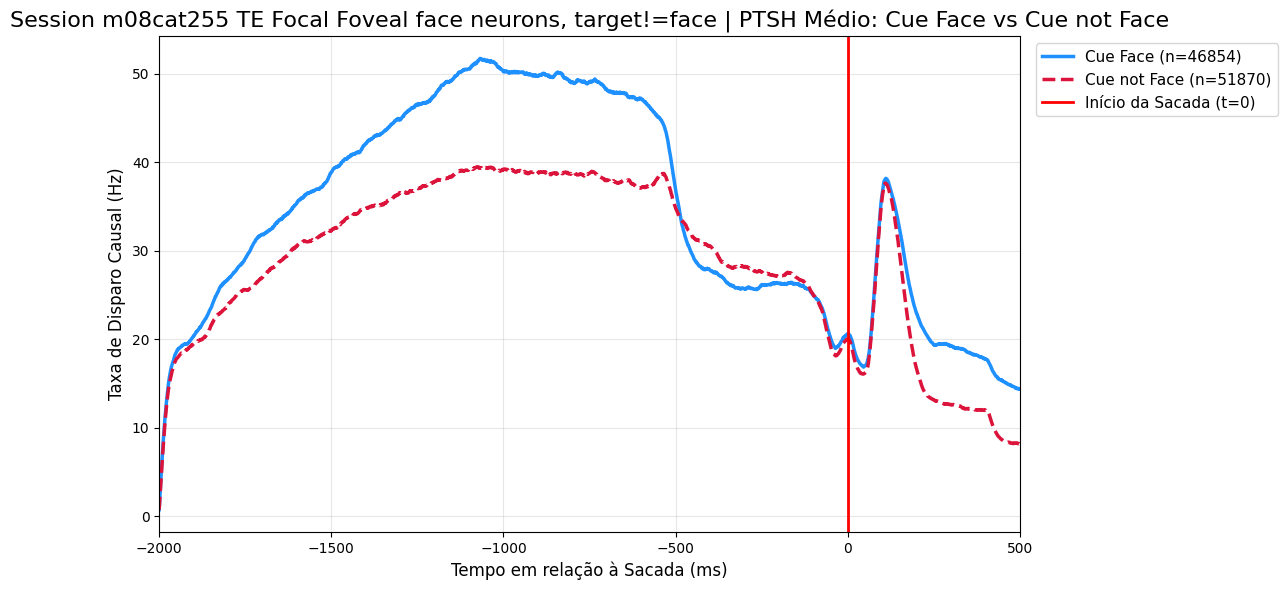

Processando PSTH Causal para [Cue Face]...
Processando PSTH Causal para [Cue not Face]...


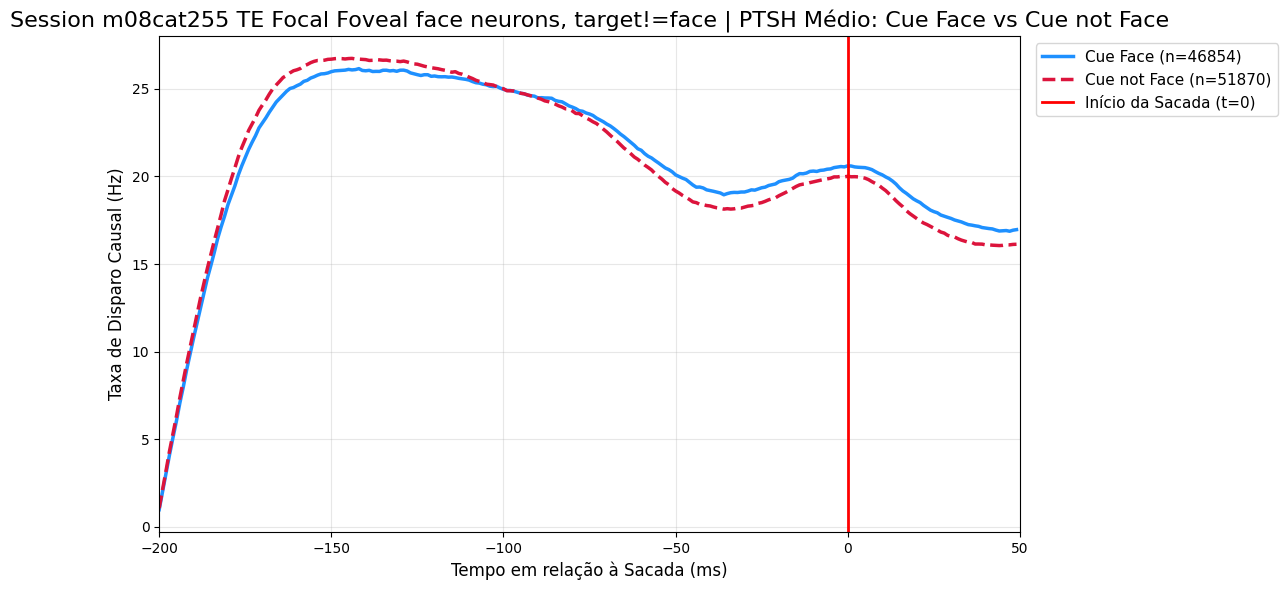

In [29]:
df_trials_face_NOT_FACE_TRIALS = df_trials_face[df_trials_face['imgsacc_cath']!='face']
STR_DETAILS = STR_DETAILS_fix + ' face neurons, target!=face'

compare_causal_psth_saccade(df_trials_face[df_trials_face['clue_cath']=='face'], df_trials_face[df_trials_face['clue_cath']!='face'], label1="Cue Face", label2="Cue not Face", window_start_ms=-2000, window_end_ms=500)
compare_causal_psth_saccade(df_trials_face[df_trials_face['clue_cath']=='face'], df_trials_face[df_trials_face['clue_cath']!='face'], label1="Cue Face", label2="Cue not Face", window_start_ms=-200, window_end_ms=50)

STR_DETAILS = STR_DETAILS_fix

Processando PSTH Causal para [Right Target]...
Processando PSTH Causal para [Wrong Target]...


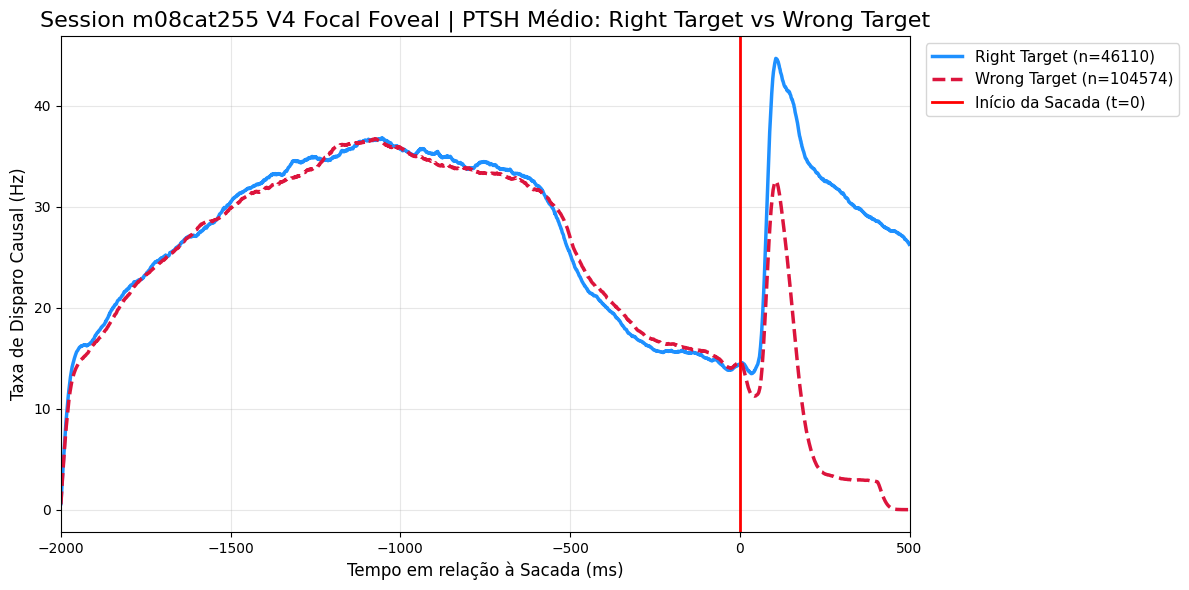

Processando PSTH Causal para [Right Target]...
Processando PSTH Causal para [Wrong Target]...


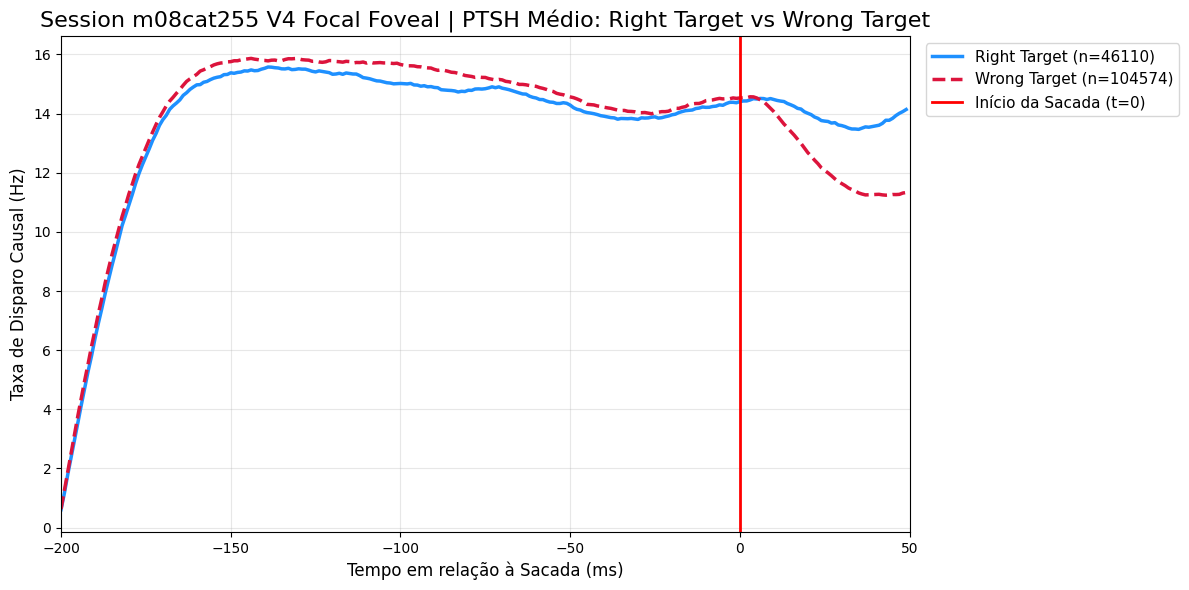

In [15]:
df_trials['fix_is_target'] = df_trials['clue_cath']==df_trials['imgsacc_cath']
compare_causal_psth_saccade(df_trials[df_trials['fix_is_target']==True], df_trials[df_trials['fix_is_target']!=True], label1="Right Target", label2="Wrong Target", window_start_ms=-2000, window_end_ms=500)
compare_causal_psth_saccade(df_trials[df_trials['fix_is_target']==True], df_trials[df_trials['fix_is_target']!=True], label1="Right Target", label2="Wrong Target", window_start_ms=-200, window_end_ms=50)

## Creating the DataFrame to train the model

In [16]:
def get_df_bins_presacc(df_trials, bins, bin_size):
    data_trials_run_model = []
    for trial in df_trials['trial_num'].unique():
        df_this_trial = df_trials[df_trials['trial_num']==trial]
        cat_target = df_this_trial.iloc[0]['imgsacc_cath']
        data_model_row = {'Y':cat_target}
        for index, row in df_this_trial.iterrows():
            neuron_id = row['neuron'][9:]
            firings = np.array(row['firings'])
            counts, _ = np.histogram(firings, bins=bins)
            FR = counts / bin_size
            for i, _ in enumerate(bins[:-1]):
                data_model_row[f'{neuron_id}_Bin{i+1}'] = FR[i]
        data_trials_run_model.append(data_model_row)
    return  pd.DataFrame(data_trials_run_model)

In [17]:
# bins = np.array([-0.2,-0.15,-0.1,-0.05,0.0])
bins = np.array([-0.4,-0.35,-0.3,-0.25,-0.2,-0.15,-0.1,-0.05,0.0,0.05,0.1,0.15,0.2, 0.25, 0.3])
bin_size = 0.05

df_run_model = get_df_bins_presacc(df_trials, bins, bin_size)
# df_run_model2 = df_run_model[df_run_model['Y'].isin(['house','face'])]
df_run_model

,Y,spk097z_Bin1,spk097z_Bin2,spk097z_Bin3,spk097z_Bin4,spk097z_Bin5,spk097z_Bin6,spk097z_Bin7,spk097z_Bin8,spk097z_Bin9,...,spk128z_Bin5,spk128z_Bin6,spk128z_Bin7,spk128z_Bin8,spk128z_Bin9,spk128z_Bin10,spk128z_Bin11,spk128z_Bin12,spk128z_Bin13,spk128z_Bin14
0,house,20.0,0.0,0.0,20.0,0.0,20.0,0.0,0.0,0.0,...,0.0,0.0,20.0,0.0,0.0,20.0,20.0,0.0,0.0,0.0
1,face,0.0,0.0,0.0,20.0,0.0,0.0,20.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,40.0,20.0,40.0,40.0
2,face,0.0,0.0,40.0,0.0,0.0,20.0,0.0,0.0,40.0,...,20.0,20.0,20.0,0.0,20.0,0.0,60.0,20.0,0.0,0.0
3,flower,0.0,0.0,20.0,20.0,0.0,0.0,0.0,20.0,0.0,...,0.0,20.0,0.0,0.0,0.0,40.0,80.0,0.0,0.0,0.0
4,face,0.0,0.0,0.0,20.0,0.0,20.0,20.0,0.0,20.0,...,20.0,0.0,0.0,20.0,0.0,0.0,40.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,house,0.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,...,0.0,20.0,60.0,20.0,60.0,20.0,40.0,80.0,40.0,0.0
1728,hand,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,20.0,...,20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1729,house,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,...,0.0,0.0,40.0,0.0,20.0,100.0,60.0,40.0,40.0,60.0
1730,house,20.0,20.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,...,20.0,20.0,60.0,20.0,60.0,20.0,60.0,0.0,0.0,0.0


In [9]:
# print(aux.preprocess_spikes(df_trials.iloc[0]['firings']))
# print(aux.preprocess_spikes(df_trials.iloc[0]['firings'],sigma=0))

# print(aux.preprocess_spikes(df_trials.iloc[1]['firings']))
# print(aux.preprocess_spikes(df_trials.iloc[1]['firings'],sigma=0))

In [32]:
def get_df_bins_presacc_smoothing(df_trials, bins, bin_size, sigma=15):
    data_trials_run_model = []
    for trial in df_trials['trial_num'].unique():
        df_this_trial = df_trials[df_trials['trial_num']==trial]
        cat_target = df_this_trial.iloc[0]['imgsacc_cath']
        data_model_row = {'Y':cat_target}
        for index, row in df_this_trial.iterrows():
            neuron_id = row['neuron'][9:]
            firings = np.array(row['firings'])
            FR = aux.preprocess_spikes(firings, sigma=sigma, bin_start=bins[0]*1000, bin_size=bin_size*1000, end_time=bins[-1]*1000)
            for i, _ in enumerate(bins[:-1]):
                data_model_row[f'{neuron_id}_Bin{i+1}'] = FR[i]
        data_trials_run_model.append(data_model_row)
    return  pd.DataFrame(data_trials_run_model)

# bins = np.array([-0.2,-0.15,-0.1,-0.05,0.0])
bins = np.array([-0.4,-0.35,-0.3,-0.25,-0.2,-0.15,-0.1,-0.05,0.0,0.05,0.1,0.15,0.2, 0.25, 0.3])
bin_size = 0.05

df_run_model2 = get_df_bins_presacc_smoothing(df_trials, bins, bin_size, sigma=15)

In [11]:
# -400 a -200
# MAIN: -200 a 0
# 0 a 200

# 8 tabelas 
# Talvez uma tabelassa seja melhor... Bin -350ms até bin 200ms
# CONFERIR SE MANTEM A ORDEM ENTRE AS 1732
# Separa entre treino e teste (80\20, 5x)
# Normalização por neurnoio (separado treino e teste) (POR TABELA? OU GERAL....)
# TESTAR SE DECODING FUNCIONA EM 0-200s DA SACADA
# HYPERPARAM TUNING COM ESSES DADOS
# TREINAR 8 MODELOS

# pra que serve a validação?

## Machine Learning

In [33]:
# df_run_model
df_run_model2

,Y,spk033a_Bin1,spk033a_Bin2,spk033a_Bin3,spk033a_Bin4,spk033a_Bin5,spk033a_Bin6,spk033a_Bin7,spk033a_Bin8,spk033a_Bin9,...,spk064z_Bin5,spk064z_Bin6,spk064z_Bin7,spk064z_Bin8,spk064z_Bin9,spk064z_Bin10,spk064z_Bin11,spk064z_Bin12,spk064z_Bin13,spk064z_Bin14
0,house,22.424833,70.144322,66.555676,50.594891,66.861508,38.902728,68.566236,16.407499,0.007013,...,65.049696,40.059443,67.885619,43.377836,55.766953,65.774429,41.709669,0.855467,0.000000,0.000000
1,face,6.499233,19.709235,0.291083,19.976226,0.023774,19.981218,0.018782,32.658995,27.334981,...,68.151841,50.962834,68.172471,56.804491,64.333546,42.945703,95.068004,69.283269,69.402385,79.042737
2,face,20.939536,19.753205,0.002644,0.000000,15.260898,7.836369,29.011942,13.983727,13.902888,...,7.555089,104.295926,64.544431,49.483024,57.554884,25.917198,162.012027,81.822346,13.332782,0.001387
3,flower,0.000000,0.000000,11.365740,8.633470,10.574571,9.425163,0.001055,11.365740,28.391848,...,39.438281,7.193312,75.194313,74.451759,141.781790,66.649758,110.890567,51.011070,0.021178,0.000000
4,face,14.128988,5.870780,19.981450,9.762771,10.254608,0.001402,0.000000,4.113152,15.879836,...,55.645381,52.061575,49.121163,40.693128,51.959887,67.410696,56.215474,44.774084,0.256421,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,house,40.188730,65.906470,112.638954,62.460816,31.217536,49.766362,80.688541,58.683818,53.773924,...,59.354096,23.374816,59.406648,6.123972,40.951087,70.704743,157.149304,50.172849,121.190234,14.429605
1728,hand,26.127366,36.375471,28.651280,43.975340,24.978385,40.788374,40.173963,1.639427,0.000000,...,61.908356,65.610215,47.035838,66.155081,7.472851,0.000434,0.000000,0.000000,0.000000,0.000000
1729,house,70.690411,68.128086,39.263754,49.919201,76.760117,27.267346,59.032675,65.487980,114.691871,...,13.672570,61.082878,44.626952,37.110472,13.252482,97.003726,109.016862,101.171223,125.963401,71.622805
1730,house,20.425349,26.596481,73.909871,123.115982,120.457165,95.967758,63.354479,59.854338,51.973593,...,62.617152,55.938930,78.057598,60.238271,88.649702,46.259496,35.190382,4.246179,0.000083,0.000000


In [34]:
df_run_model.Y.value_counts()
# df_run_model2.Y.value_counts()

face         657
house        552
flower       288
hand         210
fix_point     25
Name: Y, dtype: int64

In [23]:
# Filtrando apenas as categorias visuais reais
df_run_model = df_run_model[df_run_model['Y'].isin(['face', 'house', 'flower', 'hand'])].copy()
# df_run_model2 = df_run_model2[df_run_model2['Y'].isin(['face', 'house', 'flower', 'hand'])].copy()

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.stats import loguniform
# from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import balanced_accuracy_score

# # ==============================================================================
# # 1. FUNÇÃO DE NORMALIZAÇÃO Z-SCORE POR NEURÔNIO (SEM DATA LEAKAGE)
# # ==============================================================================
# def zscore_per_neuron(X_train, X_test):
#     """
#     Calcula mu e sigma agregando TODOS os bins de cada neurônio apenas no TREINO,
#     e aplica essa padronização no Treino e no Teste.
#     """
#     X_train_z = X_train.copy()
#     X_test_z = X_test.copy()
    
#     # Extrai os IDs únicos dos neurônios (ex: 'spk097z' de 'spk097z_Bin1')
#     neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns])
    
#     for nid in neuron_ids:
#         # Seleciona todas as colunas de bins pertencentes a este neurônio
#         cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
        
#         # Pega todos os disparos do neurônio no conjunto de treino (todas as trials x todos os bins)
#         train_values = X_train[cols_neuron].values.flatten()
        
#         mu = np.mean(train_values)
#         sigma = np.std(train_values)
        
#         # Evita divisão por zero para neurônios silenciosos
#         if sigma == 0:
#             sigma = 1e-8
            
#         # Aplica z-score no treino e no teste com as métricas do TREINO
#         X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
#         X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
#     return X_train_z, X_test_z

# # ==============================================================================
# # 2. CONFIGURAÇÃO DAS JANELAS DESLIZANTES (MOVING WINDOWS)
# # ==============================================================================
# # 14 Bins de 50ms variando de -400ms a +300ms:
# # Bin 1: [-400, -350] | ... | Bin 8: [-50, 0] | Bin 9: [0, 50] | ... | Bin 14: [250, 300]
# num_bins = 14
# # window_size_bins = 4  # 4 bins = 200ms de janela
# window_size_bins = 4  # 4 bins = 200ms de janela
# num_windows = num_bins - window_size_bins + 1  # 11 janelas no total

# # Mapeamento do centro temporal de cada janela (em ms) para o gráfico
# # Janela 1 (Bins 1..4): [-400ms a -200ms] -> Centro = -300ms
# window_centers = []
# for w in range(num_windows):
#     win_start_time = -400 + (w * 50)
#     win_end_time = win_start_time + (window_size_bins * 50)
#     window_centers.append((win_start_time + win_end_time) / 2.0)

# # ==============================================================================
# # 3. LOOP DE VALIDAÇÃO CRUZADA ANINHADA (NESTED CROSS-VALIDATION)
# # ==============================================================================
# X = df_run_model.drop(columns=['Y'])
# y = df_run_model['Y']

# num_folds = 5
# outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# # Matriz para guardar as acurácias: Linhas = Folds (5), Colunas = Janelas (11)
# fold_accuracies = np.zeros((num_folds, num_windows))

# print(f"Iniciando Nested Cross-Validation ({num_folds} folds, {num_windows} janelas temporais)...")

# for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
#     print(f"\n--- Processando Fold {fold_idx + 1}/{num_folds} ---")
    
#     # 3.1 Separação de Treino e Teste
#     X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
#     y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
#     # 3.2 Padronização Z-Score por Neurônio
#     X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
    
#     # 3.3 Otimização Bayesiana/Randomizada na Janela Pós-Sacádica
#     # Seleciona Bins 10 a 13 (+50ms a +250ms) para achar o melhor 'C' do SVM
#     post_saccade_cols = [col for col in X_train_z.columns 
#                          if any(col.endswith(f"_Bin{b}") for b in [10, 11, 12, 13])]
    
#     X_train_post = X_train_z[post_saccade_cols]
    
#     # Otimização com amostragem logarítmica para o parâmetro de regularização C
#     param_dist = {'C': loguniform(1e-4, 1e2)}
#     inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
#     search = RandomizedSearchCV(
#         estimator=SVC(kernel='linear',class_weight='balanced'),
#         param_distributions=param_dist,
#         n_iter=15,
#         cv=inner_cv,
#         scoring='accuracy',
#         random_state=42,
#         n_jobs=-1
#     )
#     search.fit(X_train_post, y_train)
    
#     best_C = search.best_params_['C']
#     print(f"Melhor parâmetro C encontrado no pós-sacádico: {best_C:.4f}")
    
#     # 3.4 Treinamento e Avaliação nas Janelas Deslizantes (Moving Windows)
#     best_svm = SVC(kernel='linear', class_weight='balanced', C=best_C)
    
#     for w_idx in range(num_windows):
#         # Seleciona os 4 bins correspondentes à janela atual
#         active_bins = [w_idx + 1 + b for b in range(window_size_bins)]
#         win_cols = [col for col in X_train_z.columns 
#                     if any(col.endswith(f"_Bin{b}") for b in active_bins)]
        
#         X_tr_win = X_train_z[win_cols]
#         X_te_win = X_test_z[win_cols]
        
#         # Treina o modelo com os hiperparâmetros fixos na janela atual do TREINO
#         best_svm.fit(X_tr_win, y_train)
        
#         # Prevê e calcula a acurácia nos dados de TESTE da mesma janela
#         preds = best_svm.predict(X_te_win)
#         acc = balanced_accuracy_score(y_test, preds)
        
#         fold_accuracies[fold_idx, w_idx] = acc

# print("\nProcessamento concluído com sucesso!")

# # ==============================================================================
# # 4. PLOTAGEM DOS RESULTADOS DE DECODIFICABILIDADE TEMPORAL
# # ==============================================================================
# mean_acc = np.mean(fold_accuracies, axis=0) * 100  # Converte para %
# sem_acc = (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100  # Erro Padrão da Média

# num_classes = len(np.unique(y))
# chance_level = (1.0 / num_classes) * 100

# plt.figure(figsize=(10, 5))

# # Sombra do período crítico pré-sacádico (-200ms a 0ms)
# plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')

# # Marcador da Sacada (t = 0)
# plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')

# # Nível do Acaso (Chance Level)
# plt.axhline(y=chance_level, color='black', linestyle=':', label=f'Chance Level ({chance_level:.1f}%)')

# window_ends = []
# for w in range(num_windows):
#     win_start_time = -400 + (w * 50)
#     win_end_time = win_start_time + (window_size_bins * 50)
#     window_ends.append(win_end_time) # Plota onde a janela TERMINA

# # Curva Principal de Decodificação (Média +- SEM entre folds)
# plt.plot(window_ends, mean_acc, color='dodgerblue', linewidth=2.5, marker='o', label='Decodificador SVM Linear')
# plt.fill_between(window_ends, mean_acc - sem_acc, mean_acc + sem_acc, color='dodgerblue', alpha=0.2)

# plt.title('Dinâmica Temporal da Decodificabilidade Preditiva da Categoria Alvo', fontsize=14)
# plt.xlabel('Final da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
# plt.ylabel('Acurácia de Decodificação (%)', fontsize=12)
# plt.ylim(0, 100)
# plt.grid(True, alpha=0.3)
# plt.legend(loc='upper left', fontsize=10)
# plt.tight_layout()
# plt.show()

In [ ]:
# para cada modelo:
# cross validation 
    # train-test-validation split
    # z-scoring (POR NEURONIO!!!! NAO POR NEURONIO-BIN)
# hyperparam tuning with bayesian search


# PESQUISAR MAIS SOBRE SELECAO DE MODELOS NESSE CONTEXTO | fazer seleção de modelos somente usando os conjuntos com mais de X neurônios? e dps testar em todos
# BIN SHUFFLING (estevao)


# dps de rodar tudo, se nao der nada, ai questione o bin size e etc....
# testar: cortar 10-20ms? por possiveis erros do eye tracker?

In [24]:
import numpy as np
import pandas as pd
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score

def zscore_per_neuron(X_train, X_test):
    """
    Calcula mu e sigma agregando TODOS os bins de cada neurônio apenas no TREINO,
    e aplica essa padronização no Treino e no Teste.
    """
    X_train_z = X_train.copy()
    X_test_z = X_test.copy()
    
    neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns])
    
    for nid in neuron_ids:
        cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
        train_values = X_train[cols_neuron].values.flatten()
        
        mu = np.mean(train_values)
        sigma = np.std(train_values)
        
        if sigma == 0:
            sigma = 1e-8
            
        X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
        X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
    return X_train_z, X_test_z


def run_temporal_decoding(df_run_model, num_bins, window_size_bins, num_folds=5, verbose=True):
    """
    Executa Nested Cross-Validation com SVM Linear e Moving Windows.
    
    Parâmetros:
    -----------
    df_run_model : pd.DataFrame
        DataFrame contendo a coluna target 'Y' e as colunas de spikes 'neuronio_BinX'.
    num_bins : int
        Número total de bins no dataset (ex: 14).
    window_size_bins : int
        Tamanho da janela deslizante em quantidade de bins (ex: 4 para 200ms, 1 para 50ms).
    num_folds : int (default=5)
        Quantidade de folds para o StratifiedKFold externo.
    verbose : bool (default=True)
        Se True, imprime o progresso do treinamento.
        
    Retorna:
    --------
    results : dict
        Dicionário contendo:
        - 'mean_acc': Acurácia média por janela (%)
        - 'sem_acc': Erro padrão da média (%)
        - 'window_centers': Array com os tempos centrais das janelas (ms)
        - 'window_ends': Array com os tempos de término (causais) das janelas (ms)
        - 'chance_level': Nível do acaso teórico baseado no número de classes (%)
        - 'fold_accuracies': Matriz bruta de acurácias (num_folds x num_windows) (%)
    """
    num_windows = num_bins - window_size_bins + 1
    
    # Mapeamento do tempo das janelas (Assumindo bins de 50ms começando em -400ms)
    window_centers = []
    window_ends = []
    for w in range(num_windows):
        win_start_time = -400 + (w * 50)
        win_end_time = win_start_time + (window_size_bins * 50)
        window_centers.append((win_start_time + win_end_time) / 2.0)
        window_ends.append(win_end_time)

    X = df_run_model.drop(columns=['Y'])
    y = df_run_model['Y']
    
    # Nível do acaso com base no número de classes únicas
    num_classes = len(np.unique(y))
    chance_level = (1.0 / num_classes) * 100

    outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_accuracies = np.zeros((num_folds, num_windows))

    if verbose:
        print(f"Iniciando Decoding Pipeline ({num_folds} folds, {num_windows} janelas temporais)...")

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        if verbose:
            print(f"--- Processando Fold {fold_idx + 1}/{num_folds} ---")
            
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # 1. Padronização Causal
        X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
        
        # 2. Tuning Bayesiano no Pós-Sacádico (Bins 10 a 13)
        post_saccade_cols = [col for col in X_train_z.columns 
                             if any(col.endswith(f"_Bin{b}") for b in [10, 11, 12, 13])]
        X_train_post = X_train_z[post_saccade_cols]
        
        param_dist = {'C': loguniform(1e-4, 1e2)}
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        
        search = RandomizedSearchCV(
            estimator=SVC(kernel='linear', class_weight='balanced'),
            param_distributions=param_dist,
            n_iter=15,
            cv=inner_cv,
            scoring='balanced_accuracy',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train_post, y_train)
        best_C = search.best_params_['C']
        
        # 3. Treino e Avaliação nas Moving Windows
        best_svm = SVC(kernel='linear', class_weight='balanced', C=best_C)
        
        for w_idx in range(num_windows):
            active_bins = [w_idx + 1 + b for b in range(window_size_bins)]
            win_cols = [col for col in X_train_z.columns 
                        if any(col.endswith(f"_Bin{b}") for b in active_bins)]
            
            X_tr_win = X_train_z[win_cols]
            X_te_win = X_test_z[win_cols]
            
            best_svm.fit(X_tr_win, y_train)
            preds = best_svm.predict(X_te_win)
            acc = balanced_accuracy_score(y_test, preds)
            
            fold_accuracies[fold_idx, w_idx] = acc

    # Prepara métricas para retorno
    mean_acc = np.mean(fold_accuracies, axis=0) * 100
    sem_acc = (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100

    return {
        'mean_acc': mean_acc,
        'sem_acc': sem_acc,
        'window_centers': np.array(window_centers),
        'window_ends': np.array(window_ends),
        'chance_level': chance_level,
        'fold_accuracies': fold_accuracies * 100
    }

In [27]:
# 1. Executa a função (ex: testando Bins isolados de 50ms)
res0 = run_temporal_decoding(
    df_run_model=df_run_model, 
    num_bins=14, 
    window_size_bins=4
)


Iniciando Decoding Pipeline (5 folds, 11 janelas temporais)...
--- Processando Fold 1/5 ---
--- Processando Fold 2/5 ---
--- Processando Fold 3/5 ---
--- Processando Fold 4/5 ---
--- Processando Fold 5/5 ---


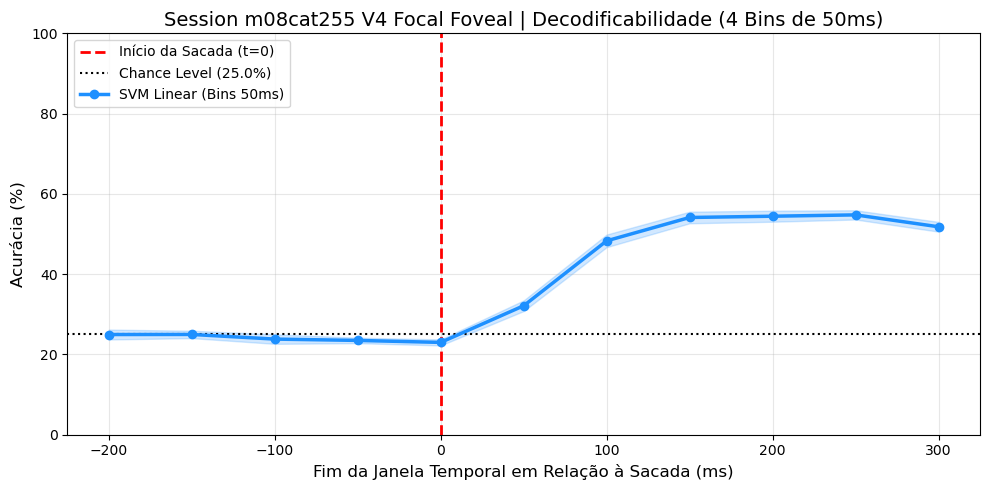

In [28]:

# 2. Plot feito totalmente por fora
plt.figure(figsize=(10, 5))

# plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')
plt.axhline(y=res0['chance_level'], color='black', linestyle=':', label=f"Chance Level ({res0['chance_level']:.1f}%)")

plt.plot(res0['window_ends'], res0['mean_acc'], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear (Bins 50ms)')
plt.fill_between(res0['window_ends'], res0['mean_acc'] - res0['sem_acc'], res0['mean_acc'] + res0['sem_acc'], color='dodgerblue', alpha=0.2)

plt.title(f'{STR_DETAILS} | Decodificabilidade (4 Bins de 50ms)', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [39]:
# 1. Executa a função (ex: testando Bins isolados de 50ms)
res = run_temporal_decoding(
    df_run_model=df_run_model, 
    num_bins=14, 
    window_size_bins=1
)


Iniciando Decoding Pipeline (5 folds, 14 janelas temporais)...
--- Processando Fold 1/5 ---
--- Processando Fold 2/5 ---
--- Processando Fold 3/5 ---
--- Processando Fold 4/5 ---
--- Processando Fold 5/5 ---


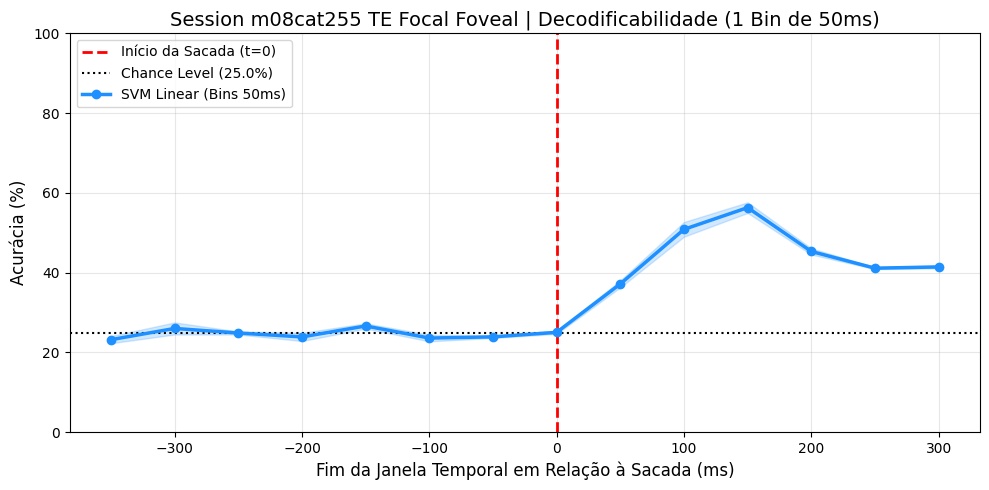

In [41]:
# 2. Plot feito totalmente por fora
plt.figure(figsize=(10, 5))

# plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')
plt.axhline(y=res['chance_level'], color='black', linestyle=':', label=f"Chance Level ({res['chance_level']:.1f}%)")

plt.plot(res['window_ends'], res['mean_acc'], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear (Bins 50ms)')
plt.fill_between(res['window_ends'], res['mean_acc'] - res['sem_acc'], res['mean_acc'] + res['sem_acc'], color='dodgerblue', alpha=0.2)

plt.title(f'{STR_DETAILS} | Decodificabilidade (1 Bin de 50ms)', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score

# Classificadores
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

def zscore_per_neuron(X_train, X_test):
    X_train_z = X_train.copy()
    X_test_z = X_test.copy()
    neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns])
    
    for nid in neuron_ids:
        cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
        train_values = X_train[cols_neuron].values.flatten()
        mu = np.mean(train_values)
        sigma = np.std(train_values) if np.std(train_values) > 0 else 1e-8
        
        X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
        X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
    return X_train_z, X_test_z


def _get_model_config(model_type):
    """Retorna o estimador base e a grade de distribuição de hiperparâmetros."""
    if model_type == 'svm_linear':
        estimator = SVC(kernel='linear', class_weight='balanced')
        param_dist = {'C': loguniform(1e-4, 1e2)}
        
    elif model_type == 'svm_rbf':
        estimator = SVC(kernel='rbf', class_weight='balanced')
        param_dist = {
            'C': loguniform(1e-2, 1e3),
            'gamma': loguniform(1e-4, 1e1)
        }
        
    elif model_type == 'mlp':
        estimator = MLPClassifier(max_iter=500, random_state=42)
        param_dist = {
            'hidden_layer_sizes': [(50,), (100,), (50, 25)],
            'alpha': loguniform(1e-4, 1e-1),
            'learning_rate_init': loguniform(1e-3, 1e-1)
        }
        
    elif model_type == 'lda':
        estimator = LDA(solver='lsqr')
        param_dist = {'shrinkage': uniform(0.0, 1.0)}
        
    elif model_type == 'xgboost':
        estimator = XGBClassifier(eval_metric='mlogloss', random_state=42)
        param_dist = {
            'max_depth': randint(2, 6),
            'learning_rate': loguniform(0.01, 0.3),
            'n_estimators': randint(50, 200)
        }
        
    elif model_type == 'catboost':
        estimator = CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42)
        param_dist = {
            'depth': randint(3, 7),
            'learning_rate': loguniform(0.01, 0.2),
            'iterations': randint(50, 200)
        }
    else:
        raise ValueError(f"model_type '{model_type}' não suportado.")
        
    return estimator, param_dist


def run_temporal_decoding(df_run_model, num_bins, window_size_bins, model_type='svm_linear', num_folds=5, verbose=True):
    num_windows = num_bins - window_size_bins + 1
    
    window_centers = []
    window_ends = []
    for w in range(num_windows):
        win_start_time = -400 + (w * 50)
        win_end_time = win_start_time + (window_size_bins * 50)
        window_centers.append((win_start_time + win_end_time) / 2.0)
        window_ends.append(win_end_time)

    X = df_run_model.drop(columns=['Y'])
    
    # Codificação dos rótulos para garantir compatibilidade com XGBoost/CatBoost
    le = LabelEncoder()
    y = le.fit_transform(df_run_model['Y'])
    
    num_classes = len(np.unique(y))
    chance_level = (1.0 / num_classes) * 100

    outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_accuracies = np.zeros((num_folds, num_windows))

    if verbose:
        print(f"\n==================================================")
        print(f"Executando Pipeline para Modelo: [{model_type.upper()}]")
        print(f"==================================================")

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        if verbose:
            print(f"--- Fold {fold_idx + 1}/{num_folds} ---")
            
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 1. Z-Score Causal
        X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
        
        # 2. Tuning na Janela Pós-Sacádica (Bins 10 a 13)
        post_saccade_cols = [col for col in X_train_z.columns 
                             if any(col.endswith(f"_Bin{b}") for b in [10, 11, 12, 13])]
        X_train_post = X_train_z[post_saccade_cols]
        
        base_estimator, param_dist = _get_model_config(model_type)
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        
        search = RandomizedSearchCV(
            estimator=base_estimator,
            param_distributions=param_dist,
            n_iter=10,
            cv=inner_cv,
            scoring='balanced_accuracy',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train_post, y_train)
        
        # 3. Treino e Avaliação nas Moving Windows com os Melhores Hiperparâmetros
        best_model = search.best_estimator_
        
        for w_idx in range(num_windows):
            active_bins = [w_idx + 1 + b for b in range(window_size_bins)]
            win_cols = [col for col in X_train_z.columns 
                        if any(col.endswith(f"_Bin{b}") for b in active_bins)]
            
            X_tr_win = X_train_z[win_cols]
            X_te_win = X_test_z[win_cols]
            
            best_model.fit(X_tr_win, y_train)
            preds = best_model.predict(X_te_win)
            acc = balanced_accuracy_score(y_test, preds)
            
            fold_accuracies[fold_idx, w_idx] = acc

    mean_acc = np.mean(fold_accuracies, axis=0) * 100
    sem_acc = (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100

    return {
        'model_type': model_type,
        'mean_acc': mean_acc,
        'sem_acc': sem_acc,
        'window_centers': np.array(window_centers),
        'window_ends': np.array(window_ends),
        'chance_level': chance_level,
        'fold_accuracies': fold_accuracies * 100
    }

In [33]:
# Lista dos modelos que você quer testar
models_to_test = ['svm_linear', 'svm_rbf', 'lda', 'mlp', 'xgboost', 'catboost']

# Dicionário para guardar todos os outputs
results_dict = {}

# Executa para cada modelo
for m in models_to_test:
    results_dict[m] = run_temporal_decoding(
        df_run_model=df_run_model,
        num_bins=14,
        # window_size_bins=1, # Testando Bins de 50ms isolados
        window_size_bins=4, # Testando Bins de 50ms isolados
        model_type=m,
        num_folds=5,
        verbose=True
    )



Executando Pipeline para Modelo: [SVM_LINEAR]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [SVM_RBF]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [LDA]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [MLP]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [XGBOOST]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [CATBOOST]
--- Fold 1/5 ---


RuntimeError: Cannot clone object CatBoostClassifier(auto_class_weights='Balanced', depth=3, iterations=98, learning_rate=0.04816677553256256, random_state=42, verbose=0), as the constructor either does not set or modifies parameter learning_rate

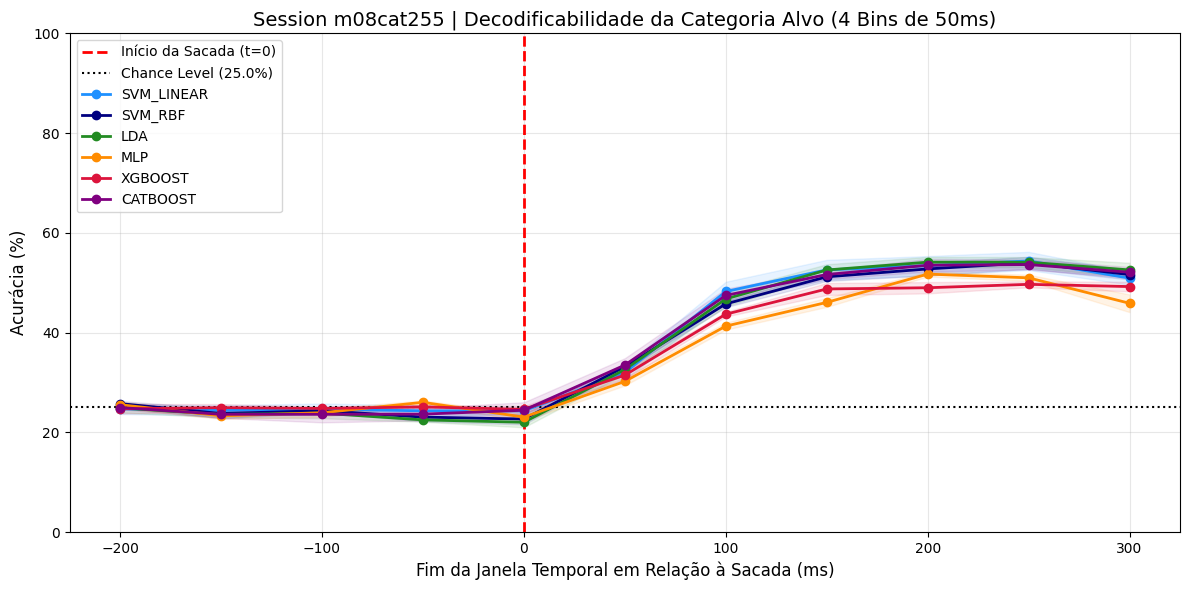

In [ ]:

# ==============================================================================
# PLOT COMPARATIVO MULTI-MODELO
# ==============================================================================
plt.figure(figsize=(12, 6))

# plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')

# Linha do Acaso (pega do primeiro resultado)
chance_val = list(results_dict.values())[0]['chance_level']
plt.axhline(y=chance_val, color='black', linestyle=':', label=f'Chance Level ({chance_val:.1f}%)')

# Paleta de cores para os modelos
colors = {
    'svm_linear': 'dodgerblue',
    'svm_rbf': 'navy',
    'lda': 'forestgreen',
    'mlp': 'darkorange',
    'xgboost': 'crimson',
    'catboost': 'purple'
}

for m in models_to_test:
    res = results_dict[m]
    plt.plot(
        res['window_ends'], 
        res['mean_acc'], 
        label=m.upper(), 
        color=colors.get(m, 'black'), 
        linewidth=2, 
        marker='o'
    )
    # Sombra leve de erro padrão
    plt.fill_between(
        res['window_ends'], 
        res['mean_acc'] - res['sem_acc'], 
        res['mean_acc'] + res['sem_acc'], 
        color=colors.get(m, 'black'), 
        alpha=0.1
    )

# plt.title(f'Session {SESSION} | Decodificabilidade da Categoria Alvo (1 Bin de 50ms)', fontsize=14)
plt.title(f'{STR_DETAILS} | Decodificabilidade da Categoria Alvo (4 Bins de 50ms)', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# Maior resolução temporal

In [14]:
import numpy as np
import pandas as pd

# bins = np.array([-0.4,-0.35,-0.3,-0.25,-0.2,-0.15,-0.1,-0.05,0.0,0.05,0.1,0.15,0.2, 0.25, 0.3])
# bin_size = 0.05


def get_df_bins_presacc_high_res(df_trials, start_time=-400, end_time=300, bin_width=50, step=5):
    """
    Gera bins de 'bin_width' ms com passos deslizantes de 'step' ms.
    Ex: Bin0 (-400 a -350), Bin1 (-395 a -345), Bin2 (-390 a -340)...
    """
    # Cria os tempos de TÉRMINO de cada bin
    t_ends = np.arange(start_time + bin_width, end_time + step, step)
    data_trials_run_model = []
    
    for trial in df_trials['trial_num'].unique():
        df_this_trial = df_trials[df_trials['trial_num']==trial]
        cat_target = df_this_trial.iloc[0]['imgsacc_cath']
        data_model_row = {'Y': cat_target}
        
        for index, row in df_this_trial.iterrows():
            neuron_id = row['neuron'][9:]
            firings = np.array(row['firings']) * 1000.0
            # Dica: se firings estiver em segundos, faça: firings = firings * 1000.0
            
            for i, t_end in enumerate(t_ends):
                t_start = t_end - bin_width
                
                # Conta spikes estritamente dentro da janela [t_start, t_end)
                count = np.sum((firings >= t_start) & (firings < t_end))
                
                # Converte para Taxa de Disparo (Hz)
                fr = count / (bin_width / 1000.0)
                
                # Salva no formato _Bin0, _Bin1, etc.
                data_model_row[f'{neuron_id}_Bin{i}'] = fr
                
        data_trials_run_model.append(data_model_row)
        
    return pd.DataFrame(data_trials_run_model)


df_run_model_highred = get_df_bins_presacc_high_res(df_trials, start_time=-400, end_time=300, bin_width=50, step=5)
df_run_model_highred

,Y,spk097z_Bin0,spk097z_Bin1,spk097z_Bin2,spk097z_Bin3,spk097z_Bin4,spk097z_Bin5,spk097z_Bin6,spk097z_Bin7,spk097z_Bin8,...,spk128z_Bin121,spk128z_Bin122,spk128z_Bin123,spk128z_Bin124,spk128z_Bin125,spk128z_Bin126,spk128z_Bin127,spk128z_Bin128,spk128z_Bin129,spk128z_Bin130
0,house,20.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,face,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,20.0,40.0,40.0,40.0
2,face,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,flower,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,face,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,house,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,40.0,40.0,20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0
1728,hand,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1729,house,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,40.0,40.0,20.0,20.0,20.0,40.0,40.0,40.0,40.0,60.0
1730,house,20.0,20.0,20.0,40.0,40.0,40.0,40.0,40.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
df_run_model_highres_step10 = get_df_bins_presacc_high_res(df_trials, start_time=-300, end_time=300, bin_width=50, step=10)
df_run_model_highres_step10

,Y,spk097z_Bin0,spk097z_Bin1,spk097z_Bin2,spk097z_Bin3,spk097z_Bin4,spk097z_Bin5,spk097z_Bin6,spk097z_Bin7,spk097z_Bin8,...,spk128z_Bin46,spk128z_Bin47,spk128z_Bin48,spk128z_Bin49,spk128z_Bin50,spk128z_Bin51,spk128z_Bin52,spk128z_Bin53,spk128z_Bin54,spk128z_Bin55
0,house,0.0,0.0,0.0,20.0,20.0,20.0,20.0,20.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,face,0.0,0.0,0.0,20.0,20.0,20.0,20.0,20.0,0.0,...,60.0,60.0,40.0,40.0,40.0,0.0,0.0,0.0,40.0,40.0
2,face,40.0,40.0,20.0,20.0,20.0,0.0,0.0,0.0,0.0,...,20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,flower,20.0,0.0,20.0,20.0,20.0,20.0,20.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,face,0.0,0.0,0.0,0.0,0.0,20.0,20.0,20.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,house,20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.0,80.0,100.0,80.0,40.0,40.0,20.0,0.0,0.0,0.0
1728,hand,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1729,house,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.0,40.0,40.0,40.0,40.0,40.0,20.0,40.0,40.0,60.0
1730,house,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# df_run_model

In [ ]:
# print(all(df_run_model_highred['spk097z_Bin0'] == df_run_model['spk097z_Bin1']))
# print(all(df_run_model_highred['spk097z_Bin10'] == df_run_model['spk097z_Bin2']))
# print(all(df_run_model_highred['spk097z_Bin20'] == df_run_model['spk097z_Bin3']))
# print(all(df_run_model_highred['spk097z_Bin30'] == df_run_model['spk097z_Bin4']))

True
True
True
True


In [39]:
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.metrics import balanced_accuracy_score


def zscore_per_neuron(X_train, X_test):
    X_train_z = X_train.copy()
    X_test_z = X_test.copy()
    neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns if '_Bin' in col])
    
    for nid in neuron_ids:
        cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
        train_values = X_train[cols_neuron].values.flatten()
        
        mu = np.mean(train_values)
        sigma = np.std(train_values)
        if sigma == 0: sigma = 1e-8
            
        X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
        X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
    return X_train_z, X_test_z


def run_temporal_decoding_high_res(df_run_model, start_time=-400, bin_width=50, step=5, window_size_ms=200, num_folds=5, verbose=True):
    # Calcula proporções da janela
    num_sub_bins = window_size_ms // bin_width # Quantos blocos de 50ms cabem em 200ms? -> 4
    offset = bin_width // step                 # Quantos passos de 5ms existem em 50ms? -> 10
    
    # Extrai IDs e total de Bins (calculando baseado em quantas colunas um neurônio possui)
    neuron_ids = list(set([col.split('_Bin')[0] for col in df_run_model.columns if '_Bin' in col]))
    total_bins = len([col for col in df_run_model.columns if col.startswith(f"{neuron_ids[0]}_Bin")])
    
    # Total de janelas possíveis sem extrapolar o número de bins
    num_windows = total_bins - (num_sub_bins - 1) * offset
    
    window_ends = []
    for w in range(num_windows):
        # O último sub-bin dessa janela dita o fim do tempo causal
        last_bin_idx = w + (num_sub_bins - 1) * offset
        win_end = start_time + bin_width + (last_bin_idx * step)
        window_ends.append(win_end)

    X = df_run_model.drop(columns=['Y'])
    y = df_run_model['Y']
    chance_level = (1.0 / len(np.unique(y))) * 100

    outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_accuracies = np.zeros((num_folds, num_windows))

    if verbose:
        print(f"High-Res Pipeline: {num_windows} janelas de {window_size_ms}ms (Passo de {step}ms).")

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        if verbose: print(f"--- Processando Fold {fold_idx + 1}/{num_folds} --- {pd.Timestamp.now()} ")
            
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # 1. Z-Score
        X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
        
        # 2. Tuning Pós-Sacádico (Procura a janela que termina em +250ms ou a mais próxima)
        target_end_time = 250
        try:
            w_post = window_ends.index(target_end_time)
        except ValueError:
            # Pega a última janela se +250 não existir exato
            w_post = len(window_ends) - 1 
            
        active_bins_post = [w_post + (k * offset) for k in range(num_sub_bins)]
        post_cols = [f"{nid}_Bin{b}" for nid in neuron_ids for b in active_bins_post]
        X_train_post = X_train_z[post_cols]
        
        # Tuning
        search = RandomizedSearchCV(
            estimator=SVC(kernel='linear', class_weight='balanced'),
            # estimator=LinearSVC(class_weight='balanced', dual=False),
            param_distributions={'C': loguniform(1e-4, 1e2)},
            n_iter=15, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
            scoring='balanced_accuracy', random_state=42, n_jobs=-1
        )
        search.fit(X_train_post, y_train)
        print('hyperparams:C=', search.best_params_['C'])
        # best_svm = LinearSVC(class_weight='balanced',  C=search.best_params_['C'], dual=False, max_iter=2000)
        best_svm = SVC(kernel='linear', class_weight='balanced', C=search.best_params_['C'])
        
        # 3. Treino/Teste nas Moving Windows de 5 em 5ms
        for w_idx in range(num_windows):
            # A mágica: Pula os bins indesejados (Ex: Bin 0, Bin 10, Bin 20, Bin 30)
            active_bins = [w_idx + (k * offset) for k in range(num_sub_bins)]
            
            # Constroi os nomes exatos das colunas (evita bug de col.endswith)
            win_cols = [f"{nid}_Bin{b}" for nid in neuron_ids for b in active_bins]
            
            best_svm.fit(X_train_z[win_cols], y_train)
            preds = best_svm.predict(X_test_z[win_cols])
            
            fold_accuracies[fold_idx, w_idx] = balanced_accuracy_score(y_test, preds)

    return {
        'mean_acc': np.mean(fold_accuracies, axis=0) * 100,
        'sem_acc': (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100,
        'window_ends': np.array(window_ends),
        'chance_level': chance_level
    }

In [ ]:
# # 1. Executa a função (ex: testando Bins isolados de 50ms)
# # res_highres_4bins =  run_temporal_decoding_high_res(df_run_model_highred, start_time=-400, bin_width=50, step=5, window_size_ms=200, num_folds=5, verbose=True)
res_highres_4bins =  run_temporal_decoding_high_res(df_run_model_highres_step10, start_time=-300, bin_width=50, step=10, window_size_ms=200, num_folds=5, verbose=True) # 20 min com linear svm
res_highres_4bins =  run_temporal_decoding_high_res(df_run_model_highres_step10, start_time=-300, bin_width=50, step=10, window_size_ms=200, num_folds=5, verbose=True) # 8 min com svm normal kernel linear;;;

High-Res Pipeline: 41 janelas de 200ms (Passo de 10ms).
--- Processando Fold 1/5 --- 2026-09-10 19:20:35.556273 
hyperparams:C= 0.0018794668241638452
--- Processando Fold 2/5 --- 2026-09-10 19:22:04.549562 
hyperparams:C= 0.0018794668241638452
--- Processando Fold 3/5 --- 2026-09-10 19:23:55.550619 
hyperparams:C= 0.0018794668241638452
--- Processando Fold 4/5 --- 2026-09-10 19:25:24.543713 
hyperparams:C= 0.0012329623163659835
--- Processando Fold 5/5 --- 2026-09-10 19:26:53.285486 
hyperparams:C= 0.017670169402947945


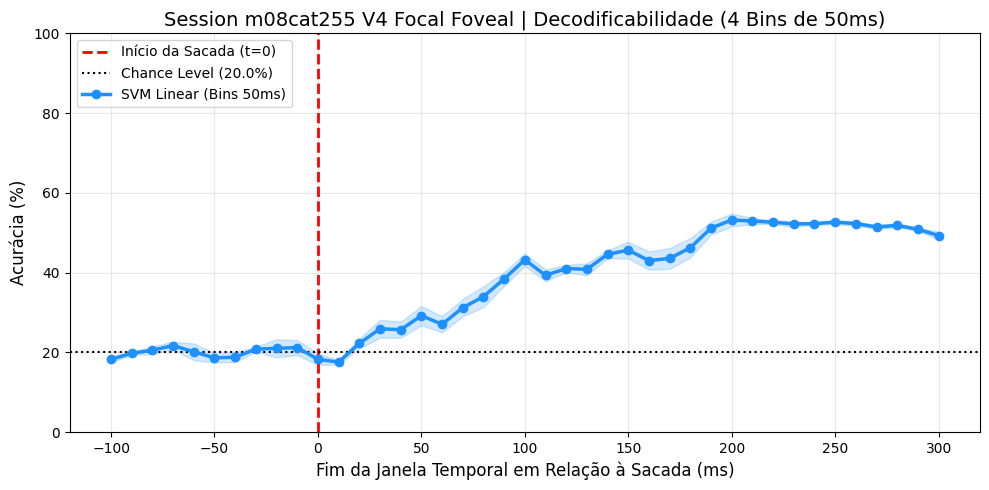

In [40]:
# 2. Plot feito totalmente por fora
plt.figure(figsize=(10, 5))

# plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')
plt.axhline(y=res_highres_4bins['chance_level'], color='black', linestyle=':', label=f"Chance Level ({res_highres_4bins['chance_level']:.1f}%)")

plt.plot(res_highres_4bins['window_ends'], res_highres_4bins['mean_acc'], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear (Bins 50ms)')
plt.fill_between(res_highres_4bins['window_ends'], res_highres_4bins['mean_acc'] - res_highres_4bins['sem_acc'], res_highres_4bins['mean_acc'] + res_highres_4bins['sem_acc'], color='dodgerblue', alpha=0.2)

plt.title(f'{STR_DETAILS} | Decodificabilidade (4 Bins de 50ms)', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

High-Res Pipeline: 131 janelas de 50ms (Passo de 5ms).
--- Processando Fold 1/5 ---
--- Processando Fold 2/5 ---
--- Processando Fold 3/5 ---
--- Processando Fold 4/5 ---
--- Processando Fold 5/5 ---


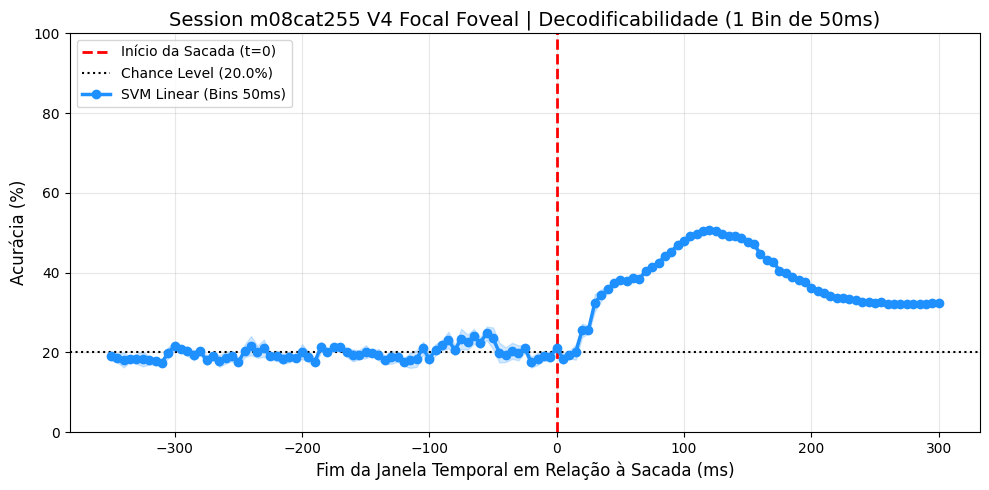

In [ ]:
# 1. Executa a função (ex: testando Bins isolados de 50ms)
res_highres_1bin =  run_temporal_decoding_high_res(df_run_model_highred, start_time=-400, bin_width=50, step=5, window_size_ms=50, num_folds=5, verbose=True)

In [ ]:
# 2. Plot feito totalmente por fora
plt.figure(figsize=(10, 5))

# plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')
plt.axhline(y=res_highres_1bin['chance_level'], color='black', linestyle=':', label=f"Chance Level ({res_highres_1bin['chance_level']:.1f}%)")

plt.plot(res_highres_1bin['window_ends'], res_highres_1bin['mean_acc'], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear (Bins 50ms)')
plt.fill_between(res_highres_1bin['window_ends'], res_highres_1bin['mean_acc'] - res_highres_1bin['sem_acc'], res_highres_1bin['mean_acc'] + res_highres_1bin['sem_acc'], color='dodgerblue', alpha=0.2)

plt.title(f'{STR_DETAILS} | Decodificabilidade (1 Bin de 50ms)', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()